In [9]:
import tensorflow as tf
import numpy as np
import random
import os

# Set a fixed seed value for reproducibility
SEED = 1
random.seed(SEED)            # Python random module
np.random.seed(SEED)         # NumPy
tf.random.set_seed(SEED)     # TensorFlow

# Enforce deterministic behavior for GPU operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # Ensure deterministic execution
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Deterministic cuDNN algorithms

# Control GPU memory allocation (prevents TensorFlow from using all GPU memory)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)  # Enable memory growth

# Restrict parallelism (ensures consistent execution order)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

import os
import scipy.io 
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
from sklearn.metrics import f1_score, classification_report
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    log_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt

## Read CWRU Bearing Data (Load - 2HP)

In [13]:
import os
import scipy.io
import numpy as np

# Define folder path and data structure
folder_path = './CWRU_BearingData_Load_2HP'
data_dict = {
    'Condition': [],
    'Fault Size (mm)': [],
    'Fault Label': [],
    'Signal': []
}

# Define configurations for each condition
conditions = [
    ('99.mat', 'Normal', 0, 0),
    ('124.mat', 'RE (Rolling element)', 0.18, 1),
    ('111.mat', 'IR (Inner ring)', 0.18, 2),
    ('137.mat', 'OR (Outer ring)', 0.18, 3),
    ('191.mat', 'RE (Rolling element)', 0.36, 4),
    ('176.mat', 'IR (Inner ring)', 0.36, 5),
    ('203.mat', 'OR (Outer ring)', 0.36, 6),
    ('228.mat', 'RE (Rolling element)', 0.54, 7),
    ('215.mat', 'IR (Inner ring)', 0.54, 8),
    ('240.mat', 'OR (Outer ring)', 0.54, 9)
]

# Load data and populate dictionary
for file_name, condition, fault_size, fault_label in conditions:
    file_path = os.path.join(folder_path, file_name)
    # Pad the file number with leading zeros to ensure three digits
    file_number = file_name.split(".")[0].zfill(3)
    signal = scipy.io.loadmat(file_path)[f'X{file_number}_DE_time'].flatten()
    data_dict['Condition'].append(condition)
    data_dict['Fault Size (mm)'].append(fault_size)
    data_dict['Fault Label'].append(fault_label)
    data_dict['Signal'].append(signal)

## Data Processing and Feature Extraction with Imbalanced Data


In [21]:
# Convert dictionary to DataFrame
df = pd.DataFrame(data_dict)

# --- Imbalance Preprocessing (Applied to Sampled Training Segments) ---
def preprocess_train_for_imbalance(segments, labels, imbalance_ratio=50):
    """
    Apply imbalance preprocessing to sampled training segments to achieve specified ratio.
    
    Args:
        segments (List[np.ndarray]): List of sampled segment arrays (n_segments, samples_per_block).
        labels (List[int]): List of corresponding fault labels.
        imbalance_ratio (int): Ratio of normal to fault segments (default: 50).
    
    Returns:
        List[np.ndarray]: List of preprocessed training segment arrays.
    """
    processed_segments = []
    # Find number of segments for normal class (label 0)
    normal_segments = next((seg for seg, lbl in zip(segments, labels) if lbl == 0), np.array([]))
    n_normal_segments = normal_segments.shape[0]
    target_fault_segments = max(1, n_normal_segments // imbalance_ratio)  # Ensure at least 1 segment
    
    for segment_array, fault_label in zip(segments, labels):
        n_segments = segment_array.shape[0]
        if n_segments == 0:
            print(f"No segments available for Fault Label {fault_label}. Skipping.")
            processed_segments.append(np.array([]).reshape(0, segment_array.shape[1]))
            continue
        # Select segments based on imbalance ratio
        target = n_normal_segments if fault_label == 0 else target_fault_segments
        selected_segments = segment_array[:min(target, n_segments)]
        processed_segments.append(selected_segments)
    return processed_segments

# --- Optimized Sampling and Data Preparation ---
def extract_segments(data, samples_per_block, interval_length, ignore_points=0):
    """
    Extract segments from data using vectorized indexing.
    
    Args:
        data (np.ndarray): Input signal data.
        samples_per_block (int): Length of each segment.
        interval_length (int): Step size between segment starts.
        ignore_points (int): Points to ignore at start and end.
    
    Returns:
        np.ndarray: Array of shape (n_segments, samples_per_block).
    """
    data = np.asarray(data).flatten()
    adjusted_length = len(data) - 2 * ignore_points
    n_segments = max(0, (adjusted_length - samples_per_block) // interval_length + 1)
    if n_segments == 0:
        return np.empty((0, samples_per_block), dtype=data.dtype)
    
    start_indices = ignore_points + np.arange(n_segments) * interval_length
    indices = start_indices[:, None] + np.arange(samples_per_block)
    return data[indices]  
    
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    # Adjust data length to ignore the first and last 'ignore_points'
    adjusted_length = len(Data) - 2 * ignore_points
    # Adjust the number of blocks
    No_of_blocks = (round(adjusted_length / interval_length) - round(samples_per_block / interval_length) - 1)
    SplitData = np.zeros([No_of_blocks, samples_per_block])  # SplitData matrix where each row is a block of samples_per_block samples
    
    for i in range(No_of_blocks):
        # Skip the first 'ignore_points' and start sampling from that position
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx:(start_idx + samples_per_block)].T  # .T transpose ensures correct orientation
    
    return SplitData  # 2D array of shape (No_of_blocks, samples_per_block)

# --- Data Preparation ---
def prepare_data_with_time_split_and_imbalance(raw_signals, n_classes, interval_length, samples_per_block, 
                                              train_ratio=0.8, imbalance_ratio=50):
    """
    Prepare data with time-based train-test split, sampling, and dynamic imbalance on training data.
    
    Args:
        raw_signals (List[np.ndarray]): List of raw signal arrays.
        n_classes (int): Number of classes.
        interval_length (int): Step size for sampling.
        samples_per_block (int): Number of samples per block.
        train_ratio (float): Fraction of data for training.
        imbalance_ratio (int): Ratio of normal to fault segments.
    
    Returns:
        tuple: (X_train, X_test, Y_train, Y_test, y_train, y_test) where
               X_ are 4D arrays for CNN, Y_ are one-hot labels, y_ are integer labels.
    """
    X_train_list, X_test_list = [], []
    Y_train_list, Y_test_list = [], []
    y_train_list, y_test_list = [], []
    
    # Store signal lengths for printing
    raw_signal_lengths = []
    post_split_train_lengths = []
    post_sampling_train_lengths = []
    imbalanced_train_lengths = []
    
    # Get fault labels and conditions from df
    fault_labels = df['Fault Label'].values
    conditions = df['Condition'].values
    
    # Print raw signal lengths before split
    print("\nRaw Signal Lengths Before Train-Test Split:")
    for class_idx, (signal, fault_label, condition) in enumerate(zip(raw_signals, fault_labels, conditions)):
        raw_length = len(signal)
        raw_signal_lengths.append((class_idx, fault_label, condition, raw_length))
        print(f"Class {class_idx} (Fault Label: {fault_label}, {condition}): {raw_length} data points")
    
    # Collect training segments for imbalance calculation
    train_segments_per_class = []
    
    for class_idx, (signal, fault_label, condition) in enumerate(zip(raw_signals, fault_labels, conditions)):
        signal = np.asarray(signal).flatten()
        train_size = int(len(signal) * train_ratio)
        
        # Time-based split
        train_signal = signal[:train_size]
        test_signal = signal[train_size:]
        
        # Store post-split training signal length
        post_split_train_length = len(train_signal)
        post_split_train_lengths.append((class_idx, fault_label, condition, post_split_train_length))
        
        # Sample segments
        train_segments = Sampling(train_signal, interval_length, samples_per_block)
        test_segments = Sampling(test_signal, interval_length, samples_per_block)
        
        # Store post-sampling training segment count
        post_sampling_segment_count = train_segments.shape[0]
        post_sampling_train_lengths.append((class_idx, fault_label, condition, post_sampling_segment_count))
        train_segments_per_class.append(train_segments)
        
        # Create labels for testing
        n_test_segments = test_segments.shape[0]
        if n_test_segments > 0:
            test_one_hot = np.zeros((n_test_segments, n_classes))
            test_one_hot[:, class_idx] = 1
            test_labels = np.full((n_test_segments, 1), class_idx)
            X_test_list.append(test_segments)
            Y_test_list.append(test_one_hot)
            y_test_list.append(test_labels)
        
        # Debugging output for each class
        print(f"\nClass {class_idx} (Fault Label: {fault_label}, {condition}):")
        print(f"Train signal length (post-split, before sampling): {post_split_train_length}")
        print(f"Train segments (after sampling, before imbalance): {post_sampling_segment_count} segments")
        print(f"Test signal length (raw): {len(test_signal)}")
        print(f"Test segments: {test_segments.shape[0]} segments")
        print(f"Sample train data (first 5 elements): {train_segments[0][:5] if post_sampling_segment_count > 0 else 'Empty'}")
        print(f"Sample test data (first 5 elements): {test_segments[0][:5] if n_test_segments > 0 else 'Empty'}")
    
    # Apply imbalance preprocessing to training segments
    train_segments_processed = preprocess_train_for_imbalance(
        train_segments_per_class, fault_labels, imbalance_ratio
    )
    
    # Store imbalanced training segment counts and collect training data
    for class_idx, (segments, fault_label, condition) in enumerate(zip(train_segments_processed, fault_labels, conditions)):
        n_segments = segments.shape[0]
        imbalanced_train_lengths.append((class_idx, fault_label, condition, n_segments))
        if n_segments > 0:
            train_one_hot = np.zeros((n_segments, n_classes))
            train_one_hot[:, class_idx] = 1
            train_labels = np.full((n_segments, 1), class_idx)
            X_train_list.append(segments)
            Y_train_list.append(train_one_hot)
            y_train_list.append(train_labels)
    
    # Print post-split, post-sampling, and imbalanced training lengths
    print("\nTraining Signal Lengths After Train-Test Split (Before Sampling):")
    for class_idx, fault_label, condition, length in post_split_train_lengths:
        print(f"Class {class_idx} (Fault Label: {fault_label}, {condition}): {length} data points")
    
    print("\nTraining Segments After Sampling (Before Imbalance):")
    for class_idx, fault_label, condition, segment_count in post_sampling_train_lengths:
        print(f"Class {class_idx} (Fault Label: {fault_label}, {condition}): {segment_count} segments")
    
    print("\nImbalanced Training Segments (After Imbalance Preprocessing):")
    for class_idx, fault_label, condition, segment_count in imbalanced_train_lengths:
        print(f"Class {class_idx} (Fault Label: {fault_label}, {condition}): {segment_count} segments")
    
    # Concatenate results
    X_train = np.vstack(X_train_list) if X_train_list else np.empty((0, samples_per_block))
    X_test = np.vstack(X_test_list) if X_test_list else np.empty((0, samples_per_block))
    Y_train = np.vstack(Y_train_list) if Y_train_list else np.empty((0, n_classes))
    Y_test = np.vstack(Y_test_list) if Y_test_list else np.empty((0, n_classes))
    y_train = np.vstack(y_train_list) if y_train_list else np.empty((0, 1))
    y_test = np.vstack(y_test_list) if y_test_list else np.empty((0, 1))
    
    # Reshape for CNN (n_samples, 40, 40, 1)
    X_2D_train = X_train.reshape(-1, 40, 40, 1) if X_train.size > 0 else np.empty((0, 40, 40, 1))
    X_2D_test = X_test.reshape(-1, 40, 40, 1) if X_test.size > 0 else np.empty((0, 40, 40, 1))
    
    # Final debugging output
    print(f"\nFinal X_train shape: {X_2D_train.shape}")
    print(f"Sample X_train values (first 5 elements): {X_train[0][:5] if X_train.size > 0 else 'Empty'}")
    print(f"Final Y_train shape: {Y_train.shape}")
    print(f"Sample Y_train values (first 5): {Y_train[:5] if Y_train.size > 0 else 'Empty'}")
    print(f"Final y_train shape: {y_train.shape}")
    print(f"Sample y_train values (first 5): {y_train[:5] if y_train.size > 0 else 'Empty'}")
    print(f"\nFinal X_test shape: {X_2D_test.shape}")
    print(f"Sample X_test values (first 5 elements): {X_test[0][:5] if X_test.size > 0 else 'Empty'}")
    print(f"Final Y_test shape: {Y_test.shape}")
    print(f"Sample Y_test values (first 5): {Y_test[:5] if Y_test.size > 0 else 'Empty'}")
    print(f"Final y_test shape: {y_test.shape}")
    print(f"Sample y_test values (first 5): {y_test[:5] if y_test.size > 0 else 'Empty'}")
    
    return X_2D_train, X_2D_test, Y_train, Y_test, y_train, y_test

# --- Execution ---
interval_length = 320
samples_per_block = 1600
n_classes = 10
train_ratio = 0.8
imbalance_ratio = 50

# Use raw signals for time-based split
raw_signals = df['Signal'].tolist()
X_2D_train, X_2D_test, Y_train, Y_test, y_label_train, y_label_test = prepare_data_with_time_split_and_imbalance(
    raw_signals, n_classes, interval_length, samples_per_block, train_ratio, imbalance_ratio
)


Raw Signal Lengths Before Train-Test Split:
Class 0 (Fault Label: 0, Normal): 485063 data points
Class 1 (Fault Label: 1, RE (Rolling element)): 486804 data points
Class 2 (Fault Label: 2, IR (Inner ring)): 485643 data points
Class 3 (Fault Label: 3, OR (Outer ring)): 486804 data points
Class 4 (Fault Label: 4, RE (Rolling element)): 487384 data points
Class 5 (Fault Label: 5, IR (Inner ring)): 487964 data points
Class 6 (Fault Label: 6, OR (Outer ring)): 486804 data points
Class 7 (Fault Label: 7, RE (Rolling element)): 487384 data points
Class 8 (Fault Label: 8, IR (Inner ring)): 491446 data points
Class 9 (Fault Label: 9, OR (Outer ring)): 487964 data points

Class 0 (Fault Label: 0, Normal):
Train signal length (post-split, before sampling): 388050
Train segments (after sampling, before imbalance): 1207 segments
Test signal length (raw): 97013
Test segments: 297 segments
Sample train data (first 5 elements): [ 0.06425354  0.06300185 -0.00438092 -0.03588185 -0.02399077]
Sample test

In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
# from sklearn.preprocessing import StandardScaler, label_binarize
# import numpy as np

# # Sampling function
# def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
#     """
#     Split signal data into blocks with specified intervals and block size.
    
#     Args:
#         Data (np.array): Input signal data.
#         interval_length (int): Step size for sampling.
#         samples_per_block (int): Number of samples per block.
#         ignore_points (int): Number of points to ignore at the start and end.
    
#     Returns:
#         np.array: Split data blocks.
#     """
#     # Adjust data length to ignore the first and last 'ignore_points'
#     adjusted_length = len(Data) - 2 * ignore_points
#     # Number of blocks
#     No_of_blocks = (round(adjusted_length / interval_length) - round(samples_per_block / interval_length) - 1)
#     SplitData = np.zeros([No_of_blocks, samples_per_block])
    
#     for i in range(No_of_blocks):
#         # Skip the first 'ignore_points' and start sampling from that position
#         start_idx = ignore_points + i * interval_length
#         SplitData[i, :] = Data[start_idx:(start_idx + samples_per_block)].T
    
#     return SplitData

# # Data preparation function
# def DataPreparation(Data, interval_length, samples_per_block):
#     """
#     Prepare data by splitting and labeling for multi-class classification.
    
#     Args:
#         Data (list): List of signal data for all classes.
#         interval_length (int): Step size for sampling.
#         samples_per_block (int): Number of samples per block.
    
#     Returns:
#         tuple: Prepared data (X), positional labels (LabelPositional), and class labels (Label).
#     """
#     for count, signal in enumerate(Data):
#         SplitData = Sampling(signal, interval_length, samples_per_block)
#         y = np.zeros([len(SplitData), 10])  # One-hot encoding
#         y[:, count] = 1
#         y1 = np.zeros([len(SplitData), 1])  # Class labels
#         y1[:, 0] = count
#         # Append data and labels
#         if count == 0:
#             X = SplitData
#             LabelPositional = y
#             Label = y1
#         else:
#             X = np.append(X, SplitData, axis=0)
#             LabelPositional = np.append(LabelPositional, y, axis=0)
#             Label = np.append(Label, y1, axis=0)
#     return X, LabelPositional, Label

# def prepare_data_with_time_split(signals, n_classes, interval_length, samples_per_block, train_ratio=0.8):
#     """
#     Prepare data with time-based train-test split and segment extraction.
    
#     Args:
#         signals (list): List of signal arrays.
#         n_classes (int): Number of classes.
#         interval_length (int): Step size for sampling.
#         samples_per_block (int): Number of samples per block.
#         train_ratio (float): Fraction of data for training (default: 0.8).
    
#     Returns:
#         tuple: (X_train, X_test, Y_train, Y_test, y_train, y_test) where
#                X_ are 4D arrays for CNN, Y_ are one-hot labels, y_ are integer labels.
#     """
#     X_train_list, X_test_list = [], []
#     Y_train_list, Y_test_list = [], []
#     y_train_list, y_test_list = [], []
    
#     for class_idx, signal in enumerate(signals):
#         signal = np.asarray(signal).flatten()
#         train_size = int(len(signal) * train_ratio)
        
#         # Time-based split
#         train_signal = signal[:train_size]
#         test_signal = signal[train_size:]
        
#         # Sample training and test segments
#         train_segments = Sampling(train_signal, samples_per_block, interval_length)
#         test_segments = Sampling(test_signal, samples_per_block, interval_length)
        
#         # Create labels for training
#         n_train_segments = train_segments.shape[0]
#         if n_train_segments > 0:
#             train_one_hot = np.zeros((n_train_segments, n_classes))
#             train_one_hot[:, class_idx] = 1
#             train_labels = np.full((n_train_segments, 1), class_idx)
#             X_train_list.append(train_segments)
#             Y_train_list.append(train_one_hot)
#             y_train_list.append(train_labels)
        
#         # Create labels for testing
#         n_test_segments = test_segments.shape[0]
#         if n_test_segments > 0:
#             test_one_hot = np.zeros((n_test_segments, n_classes))
#             test_one_hot[:, class_idx] = 1
#             test_labels = np.full((n_test_segments, 1), class_idx)
#             X_test_list.append(test_segments)
#             Y_test_list.append(test_one_hot)
#             y_test_list.append(test_labels)
        
#         # Debugging output
#         print(f"\nClass {class_idx}:")
#         print(f"Train segments shape: {train_segments.shape}")
#         print(f"Test segments shape: {test_segments.shape}")
#         print(f"Sample train data (first 5 elements): {train_segments[0][:5] if train_segments.size > 0 else 'Empty'}")
#         print(f"Sample test data (first 5 elements): {test_segments[0][:5] if test_segments.size > 0 else 'Empty'}")
    
#     # Concatenate results
#     X_train = np.vstack(X_train_list) if X_train_list else np.empty((0, samples_per_block))
#     X_test = np.vstack(X_test_list) if X_test_list else np.empty((0, samples_per_block))
#     Y_train = np.vstack(Y_train_list) if Y_train_list else np.empty((0, n_classes))
#     Y_test = np.vstack(Y_test_list) if Y_test_list else np.empty((0, n_classes))
#     y_train = np.vstack(y_train_list) if y_train_list else np.empty((0, 1))
#     y_test = np.vstack(y_test_list) if y_test_list else np.empty((0, 1))
    
#     # Reshape for CNN (n_samples, 40, 40, 1)
#     X_2D_train = X_train.reshape(-1, 40, 40, 1) if X_train.size > 0 else np.empty((0, 40, 40, 1))
#     X_2D_test = X_test.reshape(-1, 40, 40, 1) if X_test.size > 0 else np.empty((0, 40, 40, 1))
    
#     # Ensure integer labels are returned
#     y_label_train = y_train
#     y_label_test = y_test
    
#     # Debugging output
#     print(f"\nFinal X_train shape: {X_2D_train.shape}")
#     print(f"Sample X_train values (first 5 elements): {X_train[0][:5] if X_train.size > 0 else 'Empty'}")
#     print(f"Final Y_train shape: {Y_train.shape}")
#     print(f"Sample Y_train values (first 5): {Y_train[:5] if Y_train.size > 0 else 'Empty'}")
#     print(f"Final y_train shape: {y_label_train.shape}")
#     print(f"Sample y_train values (first 5): {y_label_train[:5] if y_label_train.size > 0 else 'Empty'}")
#     print(f"\nFinal X_test shape: {X_2D_test.shape}")
#     print(f"Sample X_test values (first 5 elements): {X_test[0][:5] if X_test.size > 0 else 'Empty'}")
#     print(f"Final Y_test shape: {Y_test.shape}")
#     print(f"Sample Y_test values (first 5): {Y_test[:5] if Y_test.size > 0 else 'Empty'}")
#     print(f"Final y_test shape: {y_label_test.shape}")
#     print(f"Sample y_test values (first 5): {y_label_test[:5] if y_label_test.size > 0 else 'Empty'}")
    
#     return X_2D_train, X_2D_test, Y_train, Y_test, y_label_train, y_label_test

# # --- Execution ---
# interval_length = 320
# samples_per_block = 1600
# n_classes = 10

# # Use imbalanced training data and raw data for testing
# train_signals = df_imbalance_train['Signal'].tolist()
# test_signals = df['Signal'].tolist()  # Raw signals for testing
# X_2D_train, X_2D_test, Y_train, Y_test, y_label_train, y_label_test = prepare_data_with_time_split(
#     train_signals, n_classes, interval_length, samples_per_block
# )

## Multiclass Classification CNN Model Training with Imbalanced Data


In [22]:
import numpy as np
import pandas as pd

# Condition mapping
condition_map = {
    0: "Normal",
    1: "RE 0.18",
    2: "IR 0.18",
    3: "OR 0.18",
    4: "RE 0.36",
    5: "IR 0.36",
    6: "OR 0.36",
    7: "RE 0.54",
    8: "IR 0.54",
    9: "OR 0.54"
}

# X_train distribution (using Y_train)
unique, counts = np.unique(np.argmax(Y_train, axis=1), return_counts=True)
df_train_orig = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique],
    'Blocks': counts
})
print("Blocks per class in X_train:")
print(df_train_orig.to_string(index=False))

# Train set distribution (using Y_train, same as above since no additional split)
train_classes = np.argmax(Y_train, axis=1)
unique_train, counts_train = np.unique(train_classes, return_counts=True)
df_train = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_train],
    'Blocks': counts_train
})
print("\nX_train_split and Y_train distribution:")
print(df_train.to_string(index=False))

# Test set distribution (using Y_test)
test_classes = np.argmax(Y_test, axis=1)
unique_test, counts_test = np.unique(test_classes, return_counts=True)
df_test = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_test],
    'Blocks': counts_test
})
print("\nX_test_split and Y_test distribution:")
print(df_test.to_string(index=False))

# y_train_split and y_test_split (same as Y_train and Y_test distributions)
print("\ny_train_split distribution (assumed):")
print(df_train.to_string(index=False))
print("\ny_test_split distribution (assumed):")
print(df_test.to_string(index=False))

Blocks per class in X_train:
Condition  Blocks
   Normal    1207
  RE 0.18      24
  IR 0.18      24
  OR 0.18      24
  RE 0.36      24
  IR 0.36      24
  OR 0.36      24
  RE 0.54      24
  IR 0.54      24
  OR 0.54      24

X_train_split and Y_train distribution:
Condition  Blocks
   Normal    1207
  RE 0.18      24
  IR 0.18      24
  OR 0.18      24
  RE 0.36      24
  IR 0.36      24
  OR 0.36      24
  RE 0.54      24
  IR 0.54      24
  OR 0.54      24

X_test_split and Y_test distribution:
Condition  Blocks
   Normal     297
  RE 0.18     298
  IR 0.18     298
  OR 0.18     298
  RE 0.36     299
  IR 0.36     299
  OR 0.36     298
  RE 0.54     299
  IR 0.54     301
  OR 0.54     299

y_train_split distribution (assumed):
Condition  Blocks
   Normal    1207
  RE 0.18      24
  IR 0.18      24
  OR 0.18      24
  RE 0.36      24
  IR 0.36      24
  OR 0.36      24
  RE 0.54      24
  IR 0.54      24
  OR 0.54      24

y_test_split distribution (assumed):
Condition  Blocks
   N

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
print(f"X_2D_train shape: {X_2D_train.shape}")  # Expected: (num_samples, 1600, 1)
print(f"X_2D_test shape: {X_2D_test.shape}")    # Expected: (num_samples, 1600, 1)
input_shape = (40,40,1)   # Reshaped input


class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()

    def CreateModel(self):
        model = Sequential([
            # Input shape: (40, 40, 1)
            Conv2D(32, (3, 3), activation='relu', input_shape=(40, 40, 1), padding='same'),
            MaxPooling2D((2, 2)),  # Output: (20, 20, 32)
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            MaxPooling2D((2, 2)),  # Output: (10, 10, 64)
            Conv2D(128, (3, 3), activation='relu', padding='same'),
            MaxPooling2D((2, 2)),  # Output: (5, 5, 128)
            Flatten(),  # Output: (None, 5 * 5 * 128) = (None, 3200)
            Dense(128, activation='relu'),  # Accepts 3200 units
            Dropout(0.5),
            Dense(10, activation='softmax')  # 10 classes
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        return model

X_2D_train shape: (1423, 40, 40, 1)
X_2D_test shape: (2986, 40, 40, 1)


In [41]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, balanced_accuracy_score

# Condition mapping
condition_map = {
    0: "Normal",
    1: "RE 0.18",
    2: "IR 0.18",
    3: "OR 0.18",
    4: "RE 0.36",
    5: "IR 0.36",
    6: "OR 0.36",
    7: "RE 0.54",
    8: "IR 0.54",
    9: "OR 0.54"
}

# Training with k-fold validation
foldername = "CNN1D_results/Imbalanced-Ratio/"
kSplits = 5
accuracy_1D = []
precision_1D = []
recall_1D = []
f1_1D = []
log_loss_1D = []
balanced_accuracy_1D = []
accuracy_1D_test = []
precision_1D_test = []
recall_1D_test = []
f1_1D_test = []
log_loss_1D_test = []
balanced_accuracy_1D_test = []

# Initialize arrays for validation predictions across folds
n_train_samples = Y_train.shape[0]
pred_all_val = np.zeros((n_train_samples, 10))  # Store validation predictions
y_val_true = np.zeros((n_train_samples, 10))    # Store true validation labels
kfold_test_len = []                             # Store size of each validation fold
fl1 = 0

early_stop = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
kfold = StratifiedKFold(n_splits=kSplits, random_state=42, shuffle=True)

# Train the model with k-fold cross-validation
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_2D_train, y_label_train.flatten())):
    checkpoint_filepath = foldername + f"best_model_fold_{fold+1}.h5"
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    Classification_2D = CNN_2D()
    history = Classification_2D.model.fit(
        X_2D_train[train_idx], Y_train[train_idx],
        validation_data=(X_2D_train[val_idx], Y_train[val_idx]),
        epochs=200,
        verbose=1,
        callbacks=[checkpoint, early_stop]
    )
    print(f"Best model saved at: {checkpoint_filepath}")
    CNN_2D_best_model = load_model(checkpoint_filepath)
    print("Best model loaded successfully!")

    # Store validation predictions
    fl2 = fl1 + len(val_idx)
    pred_all_val[fl1:fl2, :] = CNN_2D_best_model.predict(X_2D_train[val_idx])
    y_val_true[fl1:fl2, :] = Y_train[val_idx]
    kfold_test_len.append(fl2 - fl1)
    fl1 = fl2

    # Train set metrics (for the current fold's training data)
    y_pred_proba_train = CNN_2D_best_model.predict(X_2D_train[train_idx])
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(Y_train[train_idx], axis=1)

    accuracy_1D.append(accuracy_score(y_true_train, y_pred_train))
    precision_1D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_1D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_1D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_1D.append(log_loss(Y_train[train_idx], y_pred_proba_train))
    balanced_accuracy_1D.append(balanced_accuracy_score(y_true_train, y_pred_train))

    # Test set metrics
    y_pred_proba_test = CNN_2D_best_model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(Y_test, axis=1)

    accuracy_1D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_1D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_1D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_1D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    log_loss_1D_test.append(log_loss(Y_test, y_pred_proba_test))
    balanced_accuracy_1D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

# Print average metrics across folds
print("\nAverage Training Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_1D):.4f} ± {np.std(accuracy_1D):.4f}")
print(f"Precision: {np.mean(precision_1D):.4f} ± {np.std(precision_1D):.4f}")
print(f"Recall: {np.mean(recall_1D):.4f} ± {np.std(recall_1D):.4f}")
print(f"F1 Score: {np.mean(f1_1D):.4f} ± {np.std(f1_1D):.4f}")
print(f"Log Loss: {np.mean(log_loss_1D):.4f} ± {np.std(log_loss_1D):.4f}")
print(f"Balanced Accuracy: {np.mean(balanced_accuracy_1D):.4f} ± {np.std(balanced_accuracy_1D):.4f}")

print("\nAverage Test Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_1D_test):.4f} ± {np.std(accuracy_1D_test):.4f}")
print(f"Precision: {np.mean(precision_1D_test):.4f} ± {np.std(precision_1D_test):.4f}")
print(f"Recall: {np.mean(recall_1D_test):.4f} ± {np.std(recall_1D_test):.4f}")
print(f"F1 Score: {np.mean(f1_1D_test):.4f} ± {np.std(f1_1D_test):.4f}")
print(f"Log Loss: {np.mean(log_loss_1D_test):.4f} ± {np.std(log_loss_1D_test):.4f}")
print(f"Balanced Accuracy: {np.mean(balanced_accuracy_1D_test):.4f} ± {np.std(balanced_accuracy_1D_test):.4f}")

# Distribution printing (from previous request)
unique, counts = np.unique(np.argmax(Y_train, axis=1), return_counts=True)
df_train_orig = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique],
    'Blocks': counts
})
print("\nBlocks per class in X_train:")
print(df_train_orig.to_string(index=False))

train_classes = np.argmax(Y_train, axis=1)
unique_train, counts_train = np.unique(train_classes, return_counts=True)
df_train = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_train],
    'Blocks': counts_train
})
print("\nX_train_split and Y_train distribution:")
print(df_train.to_string(index=False))

test_classes = np.argmax(Y_test, axis=1)
unique_test, counts_test = np.unique(test_classes, return_counts=True)
df_test = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_test],
    'Blocks': counts_test
})
print("\nX_test_split and Y_test distribution:")
print(df_test.to_string(index=False))

print("\ny_train_split distribution (assumed):")
print(df_train.to_string(index=False))
print("\ny_test_split distribution (assumed):")
print(df_test.to_string(index=False))

Epoch 1/200


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-25 15:57:27.763569: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown a

35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7271 - loss: 1.8257
Epoch 1: val_accuracy improved from -inf to 0.86316, saving model to CNN1D_results/Imbalanced-Ratio/best_model_fold_1.h5


36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.7324 - loss: 1.7959 - val_accuracy: 0.8632 - val_loss: 0.3427
Epoch 2/200
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8544 - loss: 0.4207
Epoch 2: val_accuracy improved from 0.86316 to 0.87719, saving model to CNN1D_results/Imbalanced-Ratio/best_model_fold_1.h5


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.8551 - loss: 0.4174 - val_accuracy: 0.8772 - val_loss: 0.2961
Epoch 3/200
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8584 - loss: 0.3529
Epoch 3: val_accuracy improved from 0.87719 to 0.89474, saving model to CNN1D_results/Imbalanced-Ratio/best_model_fold_1.h5


...

36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9890 - loss: 0.0288 - val_accuracy: 0.9930 - val_loss: 0.0400
Epoch 54/200
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9944 - loss: 0.0187
Epoch 54: val_accuracy did not improve from 0.99296
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9943 - loss: 0.0189 - val_accuracy: 0.9789 - val_loss: 0.0426
Epoch 55/200
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9913 - loss: 0.0282
Epoch 55: val_accuracy did not improve from 0.99296
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9577 - val_loss: 0.1173
Epoch 56/200
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9737 - loss: 0.0693
Epoch 56: val_accuracy did not improve from 0.99296
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.9738 - loss: 0.0690 - val_accuracy: 0.9683 - val_loss: 0.1230
Epoch 57/200
35/36 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9836 - loss: 0.0386
Epoch 57: val_accuracy did not imp

36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9953 - loss: 0.0169 - val_accuracy: 0.9965 - val_loss: 0.0349
Epoch 99/200
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9928 - loss: 0.0187
Epoch 99: val_accuracy did not improve from 0.99648
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9927 - loss: 0.0193 - val_accuracy: 0.9683 - val_loss: 0.1077
Epoch 100/200
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9826 - loss: 0.0417
Epoch 100: val_accuracy did not improve from 0.99648
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9827 - loss: 0.0416 - val_accuracy: 0.9718 - val_loss: 0.1044
Epoch 101/200
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9848 - loss: 0.0455
Epoch 101: val_accuracy did not improve from 0.99648
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9851 - loss: 0.0452 - val_accuracy: 0.9859 - val_loss: 0.0349
Epoch 102/200
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9909 - loss: 0.0330
Epoch 102: val_accuracy did

Best model saved at: CNN1D_results/Imbalanced-Ratio/best_model_fold_5.h5
Best model loaded successfully!
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

2025-06-25 18:41:54.579183: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-06-25 18:41:54.580152: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step

Average Training Metrics Across Folds:
Accuracy: 1.0000 ± 0.0000
Precision: 1.0000 ± 0.0000
Recall: 1.0000 ± 0.0000
F1 Score: 1.0000 ± 0.0000
Log Loss: 0.0003 ± 0.0002
Balanced Accuracy: 1.0000 ± 0.0000

Average Test Metrics Across Folds:
Accuracy: 0.7758 ± 0.0288
Precision: 0.7932 ± 0.0280
Recall: 0.7758 ± 0.0288
F1 Score: 0.7708 ± 0.0320
Log Loss: 1.0929 ± 0.1993
Balanced Accuracy: 0.7758 ± 0.0288

Blocks per class in X_train:
Condition  Blocks
   Normal    1207
  RE 0.18      24
  IR 0.18      24
  OR 0.18      24
  RE 0.36      24
  IR 0.36      24
  OR 0.36      24
  RE 0.54      24
  IR 0.54      24
  OR 0.54      24

X_train_split and Y_train distribution:
Condition  Blocks
   Normal    1207
  RE 0.18      24
  IR 0.18      24
  OR 0.18      24
  RE 0.36      24
  IR 0.36      24
  OR 0.36      24
  RE 0.54      24
  IR 0.54      24
  OR 0.54      24

X_test_spl

## Multiclass Classification CNN Model Evaluation with Imbalanced Data


Train Accuracy: 100.00%
Test Accuracy: 77.58%
Train Precision: 100.00%
Test Precision: 79.32%
Train Recall: 100.00%
Test Recall: 77.58%
Train F1-score: 100.00%
Test F1-score: 77.58%
Train Log Loss: 0.0003
Test Log Loss: 1.0929
Train Balanced Accuracy: 100.00%
Test Balanced Accuracy: 77.58%
 6/45 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

2025-06-25 19:00:26.501324: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-06-25 19:00:26.503364: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


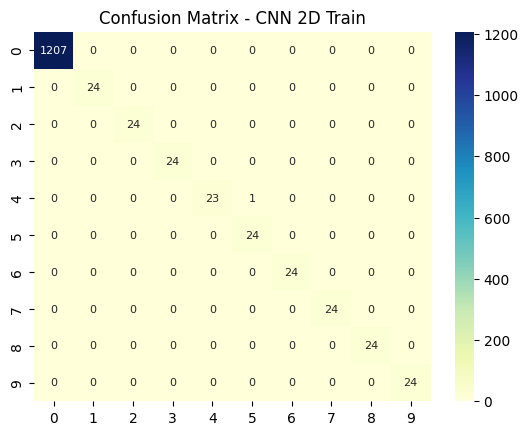

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


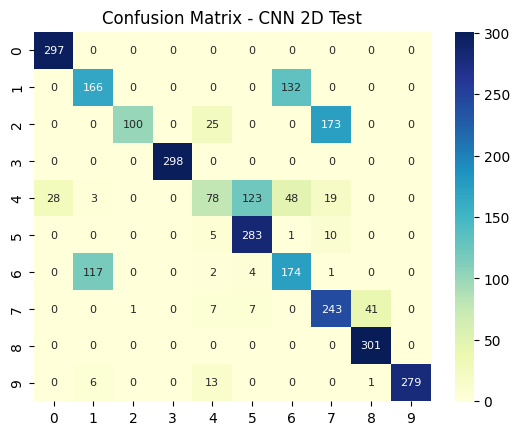

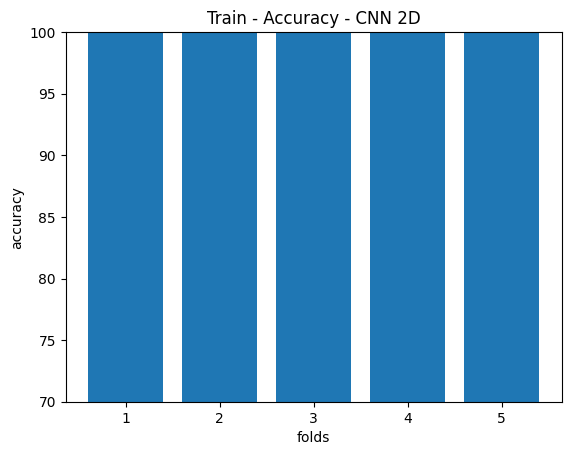

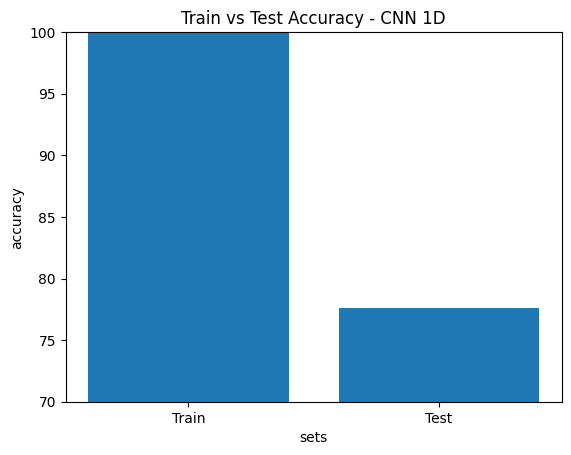

In [44]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_1D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_1D_test) * 100
CNN_2D_train_precision = np.mean(precision_1D) * 100
CNN_2D_test_precision = np.mean(precision_1D_test) * 100
CNN_2D_train_recall = np.mean(recall_1D) * 100
CNN_2D_test_recall = np.mean(recall_1D_test) * 100
CNN_2D_train_f1 = np.mean(f1_1D) * 100
CNN_2D_test_f1 = np.mean(f1_1D_test) * 100
CNN_2D_train_log_loss = np.mean(log_loss_1D)
CNN_2D_test_log_loss = np.mean(log_loss_1D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_1D) * 100  # Average balanced accuracy for train set
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_1D_test) * 100  # Average balanced accuracy for test set

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1-score: {CNN_2D_train_recall:.2f}%")
print(f"Test F1-score: {CNN_2D_test_recall:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

# Confusion Matrix Calculation

def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.predict(X)  # Use Model.model instead of Model
    y_pred = np.argmax(y_pred_proba, axis=1)  # Convert probabilities to class labels
    y_true = np.argmax(y, axis=1)  # Convert one-hot labels to class indices
    return confusion_matrix(y_true, y_pred)

# Plot results - CNN 1D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_train, Y_train), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_test, Y_test), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_1D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 1D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()